In [ ]:
import numpy as np
import os
import re

def load_viewpoint_poses(folder_path):
    """
    Loads all .npy pose files from a directory into a list, 
    sorted numerically by the index in the filename.
    """
    # Regex to capture the index number from 'viewpoint_pose_X.npy'
    def extract_number(filename):
        match = re.search(r'viewpoint_pose_(\d+)\.npy', filename)
        return int(match.group(1)) if match else -1

    # Filter for .npy files and sort them (0, 1, 2... instead of 0, 1, 10...)
    npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    npy_files.sort(key=extract_number)

    # Load data into list
    viewpoint_poses = []
    for file_name in npy_files:
        full_path = os.path.join(folder_path, file_name)
        try:
            pose = np.load(full_path)
            viewpoint_poses.append(pose)
        except Exception as e:
            print(f"Error loading {file_name}: {e}")

    return viewpoint_poses

# Usage
path = r"viewpoints_candidate/testing_data/analyze_2_constrained"
viewpoint_poses = load_viewpoint_poses(path)

print(f"Loaded {len(viewpoint_poses)} matrices.")
if viewpoint_poses:
    print("Example of first matrix:\n", viewpoint_poses[0])


Loaded 16 matrices.
Example of first matrix:
 [[-9.96194698e-01  1.21998665e-16 -8.71557427e-02  4.02555132e+01]
 [ 1.33138180e-16  1.00000000e+00 -1.21998665e-16  0.00000000e+00]
 [ 8.71557427e-02 -1.33138180e-16 -9.96194698e-01  4.60122622e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
sd


In [ ]:
# VIEWPOINT VISUALIZATION #

import open3d as o3d
import numpy as np
from scipy.spatial.transform import Rotation as R


def pose_to_matrix(pose):
    """
    Converts [x, y, z, roll, pitch, yaw] in degrees to a 4x4 transformation matrix.
    If zyz=True, assumes the input is in ZYZ Euler Angles, otherwise XYZ Euler Angles.
    
    Args:
    - pose (list or array): [x, y, z, roll, pitch, yaw] in degrees.
    - zyz (bool): If True, interprets the last three values as ZYZ Euler angles. 
                  If False, uses XYZ Euler angles (default).
    
    Returns:
    - T (ndarray): The 4x4 homogeneous transformation matrix.
    """
    x, y, z = pose[:3]   # Translation vector
    roll, pitch, yaw = pose[3:]  # Rotation angles in degrees

    # Convert XYZ Euler Angles to a 3x3 rotation matrix
    rot_matrix = R.from_euler('XYZ', [roll, pitch, yaw], degrees=True).as_matrix()

    # Build the 4x4 Homogeneous Transformation Matrix
    T = np.eye(4)  # Start with the identity matrix (4x4)
    T[:3, :3] = rot_matrix  # Set the upper-left 3x3 part to the rotation matrix
    T[:3, 3] = [x, y, z]    # Set the upper-right 3x1 part to the translation vector
    return T

def visualize_transforms(matrices, axis_size=50.0):
    """
    Visualizes a single 4x4 matrix or a list/array of 4x4 matrices.
    Red = X, Green = Y, Blue = Z.
    """
    # 1. Adapt to input type: convert single matrix to a list
    if isinstance(matrices, (list, np.ndarray)) and np.array(matrices).ndim == 2:
        matrices = [matrices]
    
    geometries = []
    
    # 2. Add a World Frame at the origin for reference
    world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=axis_size, origin=[0, 0, 0]
    )
    geometries.append(world_frame)
    geometries.append(mesh)
    
    # 3. Create and transform a coordinate frame for each matrix
    for i, mat in enumerate(matrices):
        # Create a frame
        pose_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
            size=axis_size, origin=[0, 0, 0]
        )
        # Apply the transformation
        pose_frame.transform(mat)
        geometries.append(pose_frame)
        
        print(f"Frame {i} Translation: {mat[:3, 3]}")

    # 4. Visualize everything together
    print(f"Visualizing {len(matrices)} transformation(s)...")
    o3d.visualization.draw_geometries(
        geometries,
        window_name="Adaptive Pose Visualization",
        width=640, height=480
    )

def visualize_from_pose(geometries, camera_pose):
    """
    Visualize scene from a given 4x4 camera pose matrix.
    Assumes pose = camera-to-world transform.
    """

    vis = o3d.visualization.Visualizer()
    vis.create_window()

    for g in geometries:
        vis.add_geometry(g)

    ctr = vis.get_view_control()

    # --- Extract camera position and rotation ---
    cam_pos = camera_pose[:3, 3]
    R_cam = camera_pose[:3, :3]   # camera-to-world rotation

    # --- Build Open3D extrinsic (world-to-camera) ---
    extrinsic = np.eye(4)
    extrinsic[:3, :3] = R_cam.T
    extrinsic[:3, 3] = -R_cam.T @ cam_pos

    # --- Apply ---
    param = ctr.convert_to_pinhole_camera_parameters()
    param.extrinsic = extrinsic
    ctr.convert_from_pinhole_camera_parameters(param)

    vis.run()
    vis.destroy_window()

SOURCE_PATH = "workpiece/first_object.stl" #  CAD model
mesh = o3d.io.read_triangle_mesh(SOURCE_PATH)
mesh.compute_vertex_normals() # Makes the shading look better

visualize_transforms([viewpoint_poses[0], viewpoint_poses[1]])

In [1]:
# VISUALIZING SIMULATION AND ACTUAL DATA #

import numpy as np
import open3d as o3d

def camera_pov_visualization(geoms, camera_pose, show_world_frame=False, show_camera_frame=False):

    vis = o3d.visualization.Visualizer()
    vis.create_window()  

    if show_world_frame:
        world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=150)
        vis.add_geometry(world_frame)

    for g in geoms:
        vis.add_geometry(g)

    ctr = vis.get_view_control()

    # --- Extract camera pose ---
    cam_pos = camera_pose[:3, 3]
    R_cam = camera_pose[:3, :3]

    # Optional camera frame visualization
    if show_camera_frame:
        cam_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=5)
        cam_frame.rotate(R_cam, center=(0, 0, 0))
        cam_frame.translate(cam_pos)
        vis.add_geometry(cam_frame)

    # --- Build extrinsic (world → camera) ---
    extrinsic = np.eye(4)
    extrinsic[:3, :3] = R_cam.T
    extrinsic[:3, 3] = -R_cam.T @ cam_pos

    param = ctr.convert_to_pinhole_camera_parameters()
    param.extrinsic = extrinsic
    ctr.convert_from_pinhole_camera_parameters(param, allow_arbitrary=True)

    # CRITICAL: Force update the renderer BEFORE vis.run() 
    # to prevent Open3D from resetting the camera to default
    vis.poll_events()
    vis.update_renderer()

    vis.run()
    vis.destroy_window()

INDEX = f'9'
EXPERIMENT = f'analyze_2_constrained'

# See What Actual Robot See
# pcd = o3d.io.read_point_cloud(f"./pcd_data/testing_data/{EXPERIMENT}/view{INDEX}.pcd")     # actual scan unprocessed
pcd = o3d.io.read_point_cloud(f"./processed_data/{EXPERIMENT}/viewpoint_simulated_{INDEX}.pcd")                 # actual scan processed
viewpoint = np.load(f"./pcd_data/testing_data/{EXPERIMENT}/view0{INDEX}_tf.npy")
T_base2obj = np.load(f"./pcd_data/testing_data/{EXPERIMENT}/T_base2ob_yolo.npy")
camera_pov_visualization([pcd], viewpoint)
print(pcd)

# See Simulated View
# pcd = o3d.io.read_point_cloud(f"./viewpoints_candidate/testing_data/{EXPERIMENT}/viewpoint_simulated_{INDEX}.pcd") # simulated pcd
# viewpoint = np.load(f"./viewpoints_candidate/testing_data/{EXPERIMENT}/viewpoint_pose_{INDEX}.npy")
# world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=50, origin=[0, 0, 0])
# camera_pov_visualization([pcd], viewpoint)
# print(pcd)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
PointCloud with 2786 points.


In [3]:
# TEST SIDE BY SIDE SEVERAL VIEWPOINT #

INDEX = f'8'
EXPERIMENT = f'analyze_2_unconstrained'
pcd_0 = o3d.io.read_point_cloud(f"./processed_data/{EXPERIMENT}/viewpoint_simulated_{INDEX}.pcd")

INDEX = f'9'
EXPERIMENT = f'analyze_2_unconstrained'
pcd_1 = o3d.io.read_point_cloud(f"./processed_data/{EXPERIMENT}/viewpoint_simulated_{INDEX}.pcd")
pcd_1.translate([100, 0, 0] )

INDEX = f'10'
EXPERIMENT = f'analyze_2_unconstrained'
pcd_2 = o3d.io.read_point_cloud(f"./processed_data/{EXPERIMENT}/viewpoint_simulated_{INDEX}.pcd")
pcd_2.translate([200, 0, 0] )

INDEX = f'11'
EXPERIMENT = f'analyze_2_unconstrained'
pcd_3 = o3d.io.read_point_cloud(f"./processed_data/{EXPERIMENT}/viewpoint_simulated_{INDEX}.pcd")
pcd_3.translate([300, 0, 0] )

o3d.visualization.draw_geometries([pcd_0, pcd_1, pcd_2, pcd_3])

In [34]:
# VIEWPOINT VISUALIZATION WITH ERROR CLASS COLORING #

import open3d as o3d
import numpy as np
import os
import re
import pandas as pd
import matplotlib.pyplot as plt


# ── Arrow helpers ────────────────────────────────────────────────────────────

def make_arrow(direction='x', size=50.0, color=(0.6, 0.6, 0.6)):
    """
    Creates a single arrow mesh pointing along the X or Z axis.
    create_arrow() points along +Z by default; rotate 90° around Y for +X.
    """
    arrow = o3d.geometry.TriangleMesh.create_arrow(
        cylinder_radius=size * 0.05,
        cone_radius=size * 0.15,
        cylinder_height=size * 0.80,
        cone_height=size * 0.20,
        resolution=20,
    )
    if direction == 'x':
        R_align = arrow.get_rotation_matrix_from_xyz((0, np.pi / 2, 0))
        arrow.rotate(R_align, center=(0, 0, 0))
    arrow.paint_uniform_color(list(color))
    arrow.compute_vertex_normals()
    return arrow


def make_xz_arrows(transform=None, size=50.0, color=(0.6, 0.6, 0.6)):
    """Builds an XZ arrow frame (X + Z arrows merged), applies optional 4x4 transform."""
    frame = make_arrow('x', size=size, color=color) + make_arrow('z', size=size, color=color)
    if transform is not None:
        frame.transform(transform)
    return frame


# ── Coolwarm color palette ───────────────────────────────────────────────────

_cmap = plt.get_cmap('coolwarm')
CLASS_COLORS = {cls: tuple(_cmap(cls / 3.0)[:3]) for cls in range(4)}

print("Error_Class → Color mapping (coolwarm):")
for cls, rgb in CLASS_COLORS.items():
    print(f"  Class {cls}: R={rgb[0]:.2f}  G={rgb[1]:.2f}  B={rgb[2]:.2f}")


# ── Visualization function ───────────────────────────────────────────────────

def visualize_viewpoints_colored(mesh, matrices, colors_per_frame, axis_size=50.0):
    """
    Visualizes XZ arrow frames — one per viewpoint — each colored by its Error_Class.

    Args:
        mesh: Open3D mesh to show in the scene.
        matrices (list): List of 4x4 numpy pose arrays.
        colors_per_frame (list): (R, G, B) tuple per matrix, from CLASS_COLORS.
        axis_size (float): Arrow length.
    """
    if isinstance(matrices, np.ndarray) and matrices.ndim == 2:
        matrices = [matrices]

    geometries = [mesh]

    # White world-origin frame for spatial reference
    geometries.append(make_xz_arrows(transform=None, size=axis_size, color=(0.9, 0.9, 0.9)))

    for i, (mat, color) in enumerate(zip(matrices, colors_per_frame)):
        geometries.append(make_xz_arrows(transform=mat, size=axis_size, color=color))
        print(f"Frame {i:>2d}  color={tuple(round(c,2) for c in color)}  "
              f"translation={np.round(mat[:3, 3], 1)}")

    print(f"\nVisualizing {len(matrices)} viewpoint(s) with Error_Class coloring...")
    # Top-down view: camera at +Z looking down toward scene center
    o3d.visualization.draw_geometries(
        geometries,
        window_name="Viewpoint Error-Class Visualization",
        width=640, height=480,
        front=[0, 0, 1],      # camera sits above (toward +Z)
        lookat=[0, 0, 0],     # look at world origin
        up=[0, 1, 0],         # Y-axis is "up" on screen
        zoom=1.0
    )


# ── Data loading helpers ─────────────────────────────────────────────────────

def load_viewpoint_poses(folder_path):
    """Loads all viewpoint_pose_X.npy files sorted numerically."""
    def extract_number(filename):
        match = re.search(r'viewpoint_pose_(\d+)\.npy', filename)
        return int(match.group(1)) if match else -1
    npy_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.npy')],
        key=extract_number
    )
    poses = []
    for f in npy_files:
        try:
            poses.append(np.load(os.path.join(folder_path, f)))
        except Exception as e:
            print(f"Error loading {f}: {e}")
    return poses


# ── Configuration ────────────────────────────────────────────────────────────

SOURCE_PATH  = "workpiece/first_object.stl"
POSES_PATH   = r"viewpoints_candidate/testing_data/training_second"
CSV_PATH     = r"../../pointnet_pytorch_reflective/inference_results.csv"
AXIS_SIZE    = 20.0


# ── Load everything ──────────────────────────────────────────────────────────

mesh = o3d.io.read_triangle_mesh(SOURCE_PATH)
mesh.compute_vertex_normals()

viewpoint_poses = load_viewpoint_poses(POSES_PATH)
print(f"Loaded {len(viewpoint_poses)} viewpoint poses.")

df = pd.read_csv(CSV_PATH).sort_values('Original_Index').reset_index(drop=True)
print(f"Loaded {len(df)} rows from CSV.")
print(df[['Original_Index', 'Split', 'GroundTruth_CD', 'Error', 'Error_Class']].head(8))


# ── Filter: only visualize viewpoints that have a valid Error_Class ───────────
# Rows where Error_Class is NA (e.g. Training/Validation when FILTER_TO_TESTING=True)
# are skipped entirely — both the pose and the data row are excluded.

n = len(viewpoint_poses)
df_n = df.iloc[:n].copy()   # align CSV rows to viewpoint indices

valid_mask   = df_n['Error_Class'].notna()
valid_poses  = [viewpoint_poses[i] for i in df_n.index[valid_mask]]
valid_classes = df_n.loc[valid_mask, 'Error_Class'].astype(int).tolist()
colors_per_frame = [CLASS_COLORS[ec] for ec in valid_classes]

print(f"\n{valid_mask.sum()} / {n} viewpoints have a valid Error_Class and will be visualized.")
if (~valid_mask).any():
    print(f"{(~valid_mask).sum()} viewpoints skipped (Error_Class is NA).")


# ── Visualize ────────────────────────────────────────────────────────────────

if valid_poses:
    visualize_viewpoints_colored(mesh, valid_poses, colors_per_frame, axis_size=AXIS_SIZE)
else:
    print("No viewpoints to visualize — all Error_Class values are NA.")
    print("Run '# REWRITE CSV #' in testing.ipynb first to populate Error_Class.")

Error_Class → Color mapping (coolwarm):
  Class 0: R=0.23  G=0.30  B=0.75
  Class 1: R=0.67  G=0.78  B=0.99
  Class 2: R=0.97  G=0.72  B=0.61
  Class 3: R=0.71  G=0.02  B=0.15
Loaded 492 viewpoint poses.
Loaded 492 rows from CSV.
   Original_Index       Split  GroundTruth_CD     Error  Error_Class
0               0    Training       24.420240  3.275452          NaN
1               1  Validation       18.962309  2.534437          NaN
2               2    Training       17.500479  1.875418          NaN
3               3    Training       21.493956  3.967686          NaN
4               4  Validation       10.858139  1.559845          NaN
5               5    Training        8.574903  0.070834          NaN
6               6    Training        7.556761  0.443357          NaN
7               7    Training        7.170491  0.674457          NaN

74 / 492 viewpoints have a valid Error_Class and will be visualized.
418 viewpoints skipped (Error_Class is NA).
Frame  0  color=(np.float64(0.67), 

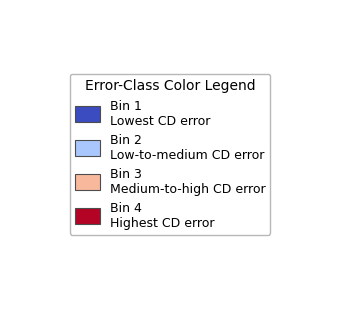

Legend saved to error_class_legend.png


In [29]:
# ERROR CLASS LEGEND #
# Shows the coolwarm color scale and what each quartile represents.
# Run this cell after the visualization cell — CLASS_COLORS must already be defined.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Quartile labels and short descriptions
QUARTILE_INFO = [
    (0, "Bin 1 ", "Lowest CD error"),
    (1, "Bin 2 ", "Low-to-medium CD error"),
    (2, "Bin 3 ", "Medium-to-high CD error"),
    (3, "Bin 4 ", "Highest CD error"),
]

fig, ax = plt.subplots(figsize=(3.5, 3.2))
ax.set_axis_off()

handles = [
    mpatches.Patch(
        facecolor=CLASS_COLORS[cls],
        edgecolor='0.3',
        linewidth=0.8,
        label=f"{label}\n{desc}"
    )
    for cls, label, desc in QUARTILE_INFO
]

legend = ax.legend(
    handles=handles,
    loc='center',
    ncol=1,
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    edgecolor='0.7',
    title='Error-Class Color Legend',
    title_fontsize=10,
    handlelength=2.0,
    handleheight=1.6,
)

plt.tight_layout()
plt.savefig('error_class_legend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Legend saved to error_class_legend.png")

In [45]:
# VIEWPOINT VISUALIZATION WITH ERROR CLASS COLORING ON ACTUAL DATA #
# Colors viewpoints by their actual Chamfer Distance (from metadata.csv),
# binned into equal-width classes using the same coolwarm palette.
# No prediction data needed — shows the ground-truth CD distribution.
#
# Requires: make_xz_arrows, visualize_viewpoints_colored, CLASS_COLORS,
#           load_viewpoint_poses  (defined in the earlier visualization cell)

import pandas as pd
import numpy as np


# ── Configuration ────────────────────────────────────────────────────────────

SOURCE_PATH   = "workpiece/first_object.stl"
POSES_PATH    = r"viewpoints_candidate/testing_data/training_second"
METADATA_PATH = r"processed_data/training_second/metadata.csv"
AXIS_SIZE     = 20.0
NUM_BINS      = 4        # number of equal-width CD bins
SHOW_ONLY_BIN = None     # set to 0/1/2/3 to visualize only one bin, or None for all


# ── Load mesh and poses ──────────────────────────────────────────────────────

mesh_actual = o3d.io.read_triangle_mesh(SOURCE_PATH)
mesh_actual.compute_vertex_normals()

viewpoint_poses_actual = load_viewpoint_poses(POSES_PATH)
print(f"Loaded {len(viewpoint_poses_actual)} viewpoint poses.")


# ── Load and bin metadata ─────────────────────────────────────────────────────

df_meta = pd.read_csv(METADATA_PATH)

# Extract numeric index from filename  (viewpoint_simulated_X.pcd → X)
df_meta['Index'] = df_meta['filename'].str.extract(r'(\d+)').astype(int)
df_meta = df_meta.sort_values('Index').reset_index(drop=True)

print(f"Loaded {len(df_meta)} rows from metadata.")
print(f"Chamfer Distance range: {df_meta['chamfer_value'].min():.2f} – {df_meta['chamfer_value'].max():.2f} mm")

# Compute equal-width bins from ALL data in this dataset
_, bins = pd.cut(df_meta['chamfer_value'], bins=NUM_BINS, retbins=True)
bins[0]  -= 1e-6   # include minimum value
bins[-1] += 1e-6   # include maximum value

df_meta['Bin'] = pd.cut(
    df_meta['chamfer_value'], bins=bins, labels=[0, 1, 2, 3]
).astype(int)

print(f"\nBin boundaries (mm):")
for b in range(NUM_BINS):
    count = (df_meta['Bin'] == b).sum()
    print(f"  Bin {b}: {bins[b]:.2f} – {bins[b+1]:.2f}  ({count} viewpoints)")


# ── Align metadata rows to viewpoint pose indices ─────────────────────────────

n = len(viewpoint_poses_actual)
df_vis = df_meta.iloc[:n].copy()

# Apply optional bin filter
if SHOW_ONLY_BIN is not None:
    valid_mask = df_vis['Bin'] == SHOW_ONLY_BIN
    active_poses  = [viewpoint_poses_actual[i] for i in df_vis.index[valid_mask]]
    active_colors = [CLASS_COLORS[SHOW_ONLY_BIN]] * len(active_poses)
    print(f"\nShowing Bin {SHOW_ONLY_BIN} only: {len(active_poses)} viewpoints.")
else:
    active_poses  = viewpoint_poses_actual
    active_colors = [CLASS_COLORS[int(b)] for b in df_vis['Bin']]
    print(f"\nShowing all {n} viewpoints, colored by Bin.")


# ── Visualize ────────────────────────────────────────────────────────────────

if active_poses:
    visualize_viewpoints_colored(mesh_actual, active_poses, active_colors, axis_size=AXIS_SIZE)
else:
    print("No viewpoints to visualize for the selected bin.")

Loaded 492 viewpoint poses.
Loaded 492 rows from metadata.
Chamfer Distance range: 5.45 – 47.16 mm

Bin boundaries (mm):
  Bin 0: 5.41 – 15.88  (463 viewpoints)
  Bin 1: 15.88 – 26.30  (27 viewpoints)
  Bin 2: 26.30 – 36.73  (1 viewpoints)
  Bin 3: 36.73 – 47.16  (1 viewpoints)

Showing all 492 viewpoints, colored by Bin.
Frame  0  color=(np.float64(0.67), np.float64(0.78), np.float64(0.99))  translation=[ 40.3   0.  460.1]
Frame  1  color=(np.float64(0.67), np.float64(0.78), np.float64(0.99))  translation=[ 34.9  20.1 460.1]
Frame  2  color=(np.float64(0.67), np.float64(0.78), np.float64(0.99))  translation=[ 20.1  34.9 460.1]
Frame  3  color=(np.float64(0.67), np.float64(0.78), np.float64(0.99))  translation=[  0.   40.3 460.1]
Frame  4  color=(np.float64(0.23), np.float64(0.3), np.float64(0.75))  translation=[-20.1  34.9 460.1]
Frame  5  color=(np.float64(0.23), np.float64(0.3), np.float64(0.75))  translation=[-34.9  20.1 460.1]
Frame  6  color=(np.float64(0.23), np.float64(0.3), np